# USGS 3DEP LiDAR Explorer                                                                                                                                      
Explore high-resolution airborne LiDAR point clouds collected by the U.S. Geological Survey's 3D Elevation Program (3DEP). Each LiDAR dataset captures the height of the ground, vegetation, and structures over a region by recording millions to billions of laser returns from aircraft. This notebook lets you pick a region of interest, download the point cloud, and turn it into a 1-meter digital elevation model (DEM) with hillshade.  
                                                        
The workflow runs in five steps:

1. **Pick an area** — draw a rectangle on the USGS 3DEP coverage map and select a dataset that intersects it from the auto-populated dropdown                            
2. **Download the point cloud** — fetch the LiDAR returns for the selected area from the public Entwine Point Tile (EPT) service
3. **Inspect the point cloud** — point count, elevation range, classification breakdown, and a 3D preview colored by elevation                                           
4. **Generate a DEM and hillshade** — rasterize the ground returns into a 1-meter DEM, then build a shaded relief view                                                   
5. **Visualize** — overlay the locally-computed hillshade against the USGS 3DEP WMS service for wider context

Linked widgets in step 1 are powered by the `sage-bbox-map` and `sage-dropdown` UI skills, which subscribe to changes in kernel variables (`USER_BBOX` triggers the dataset filter automatically when you draw a rectangle). The `usgs-lidar` data skill provides only the data primitives — `fetch_coverage()` and `filter_by_bbox()` — and knows nothing about the UI.                                    
                                                        
No coding needed — just run each cell and follow the prompts.  

In [ ]:
%reset

In [2]:
%%ask                                                                                                                                                                    
Create a USGS 3DEP coverage map with a bounding box selection tool. 
Show a dropdown of USGS 3DEP datasets that intersect the bounding box 
with under 10 million points.

I’ll consult the relevant 3DEP and Sage widget skills first so the interactive map/dropdown follows the expected notebook conventions.

I’ll verify the requested working directory exists before writing the widget script there.

The working directory exists and is empty. I’ll write a single script that fetches 3DEP coverage in memory, renders the coverage overlay with a bbox drawing tool, and links a reactive dropdown filtered to <10 million estimated points.

The script is saved. I’ll run it with the required interpreter path so the notebook displays the interactive widgets.

The runner rejected only the timeout override, not the script. I’ll rerun the same script without a timeout parameter.

⟳ Interactive widget — re-run this cell to restore map interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

⟳ Interactive widget — re-run this cell to restore dropdown interactivity.
 Widget callbacks live in the kernel and are lost when the notebook is closed.

USGS 3DEP Datasets Intersecting Selected Bounding Box (<10M estimated points) Dataset: — Draw a rectangle on the coverage map to list intersecting USGS 3DEP datasets under 10 million estimated points. —

Created the interactive USGS 3DEP coverage selector.

**What’s shown** :
- A USGS 3DEP coverage map with a bounding-box drawing tool.
- A reactive dropdown that will populate after you draw a bbox.
- The dropdown includes only intersecting datasets with **under 10 million estimated points** .

**Kernel variables created for later cells** :
- `USGS_3DEP_BBOX`: the drawn bounding box in EPSG:4326.
- `SELECTED_USGS_3DEP_DATASET_URL`: EPT URL for the selected dataset.
- `SELECTED_USGS_3DEP_DATASET_NAME`: selected dataset name.
- `SELECTED_USGS_3DEP_DATASET`: full selected dataset record.

Draw a rectangle on the map; the dropdown will refresh automatically.

I’ll consult the USGS LiDAR skill first, then create and run all working files under the specified Sage directory using `/opt/conda/bin/python`.

The skill confirms the expected workflow: download via EPT with `pyforestscan`, save LAZ with `write_las`, and use Plotly/PNG-style preview rather than Folium point maps. The working directory already contains earlier outputs, but no selected GA LAZ yet. I’ll write a self-contained script that reads the required kernel-variable names, downloads the selected bbox, writes the LAZ and summary JSON, and saves an elevation-only preview PNG.

The script is in the working directory. I’ll run it with the required interpreter path and allow extra time because EPT download and LAZ compression can take a few minutes.

The sandbox rejected the timeout override, so I’ll rerun the same script without the timeout parameter.

The download succeeded: 723,109 points were saved to LAZ, and the preview PNG and summary JSON were written. I’ll read the text summary JSON to verify the saved outputs for the report.

## USGS 3DEP point cloud download complete

**Selected dataset** : GA_Statewide_12_2018  
**Selected EPT endpoint** : `https://s3-us-west-2.amazonaws.com/usgs-lidar-public/GA_Statewide_12_2018/ept.json`  
**Bounding box** : `(-82.296782, 30.876223, -82.290258, 30.880422)`  
**Point cloud CRS** : EPSG:3857  

**LAZ file** : `/home/jovyan/work/_User-Persistent-Storage_CephBlock_/Sage_demo/_usgs_3dep_sage_/GA_Statewide_12_2018_selected_bbox.laz`  
**Summary JSON** : `/home/jovyan/work/_User-Persistent-Storage_CephBlock_/Sage_demo/_usgs_3dep_sage_/GA_Statewide_12_2018_selected_bbox_summary.json`  

## Point cloud summary

**Point count** : 723,109  
**Elevation minimum** : 34.98  
**Elevation maximum** : 62.00  
**Elevation range** : 27.02  
**Mean elevation** : 39.72  
**5th–95th percentile elevation** : 35.41 – 50.04  

## Classification breakdown

| Classification | Points | Percent |
|---|---:|---:|
| Unclassified (1) | 87,402 | 12.09% |
| Ground (2) | 42,065 | 5.82% |
| Low vegetation (3) | 64,194 | 8.88% |
| Medium vegetation (4) | 372,537 | 51.52% |
| High vegetation (5) | 155,759 | 21.54% |
| Low point / noise (7) | 810 | 0.11% |
| High noise (18) | 342 | 0.05% |

## Elevation-colored point cloud preview

The preview is colored by elevation only and was rendered from a 300,000-point sample for notebook performance.


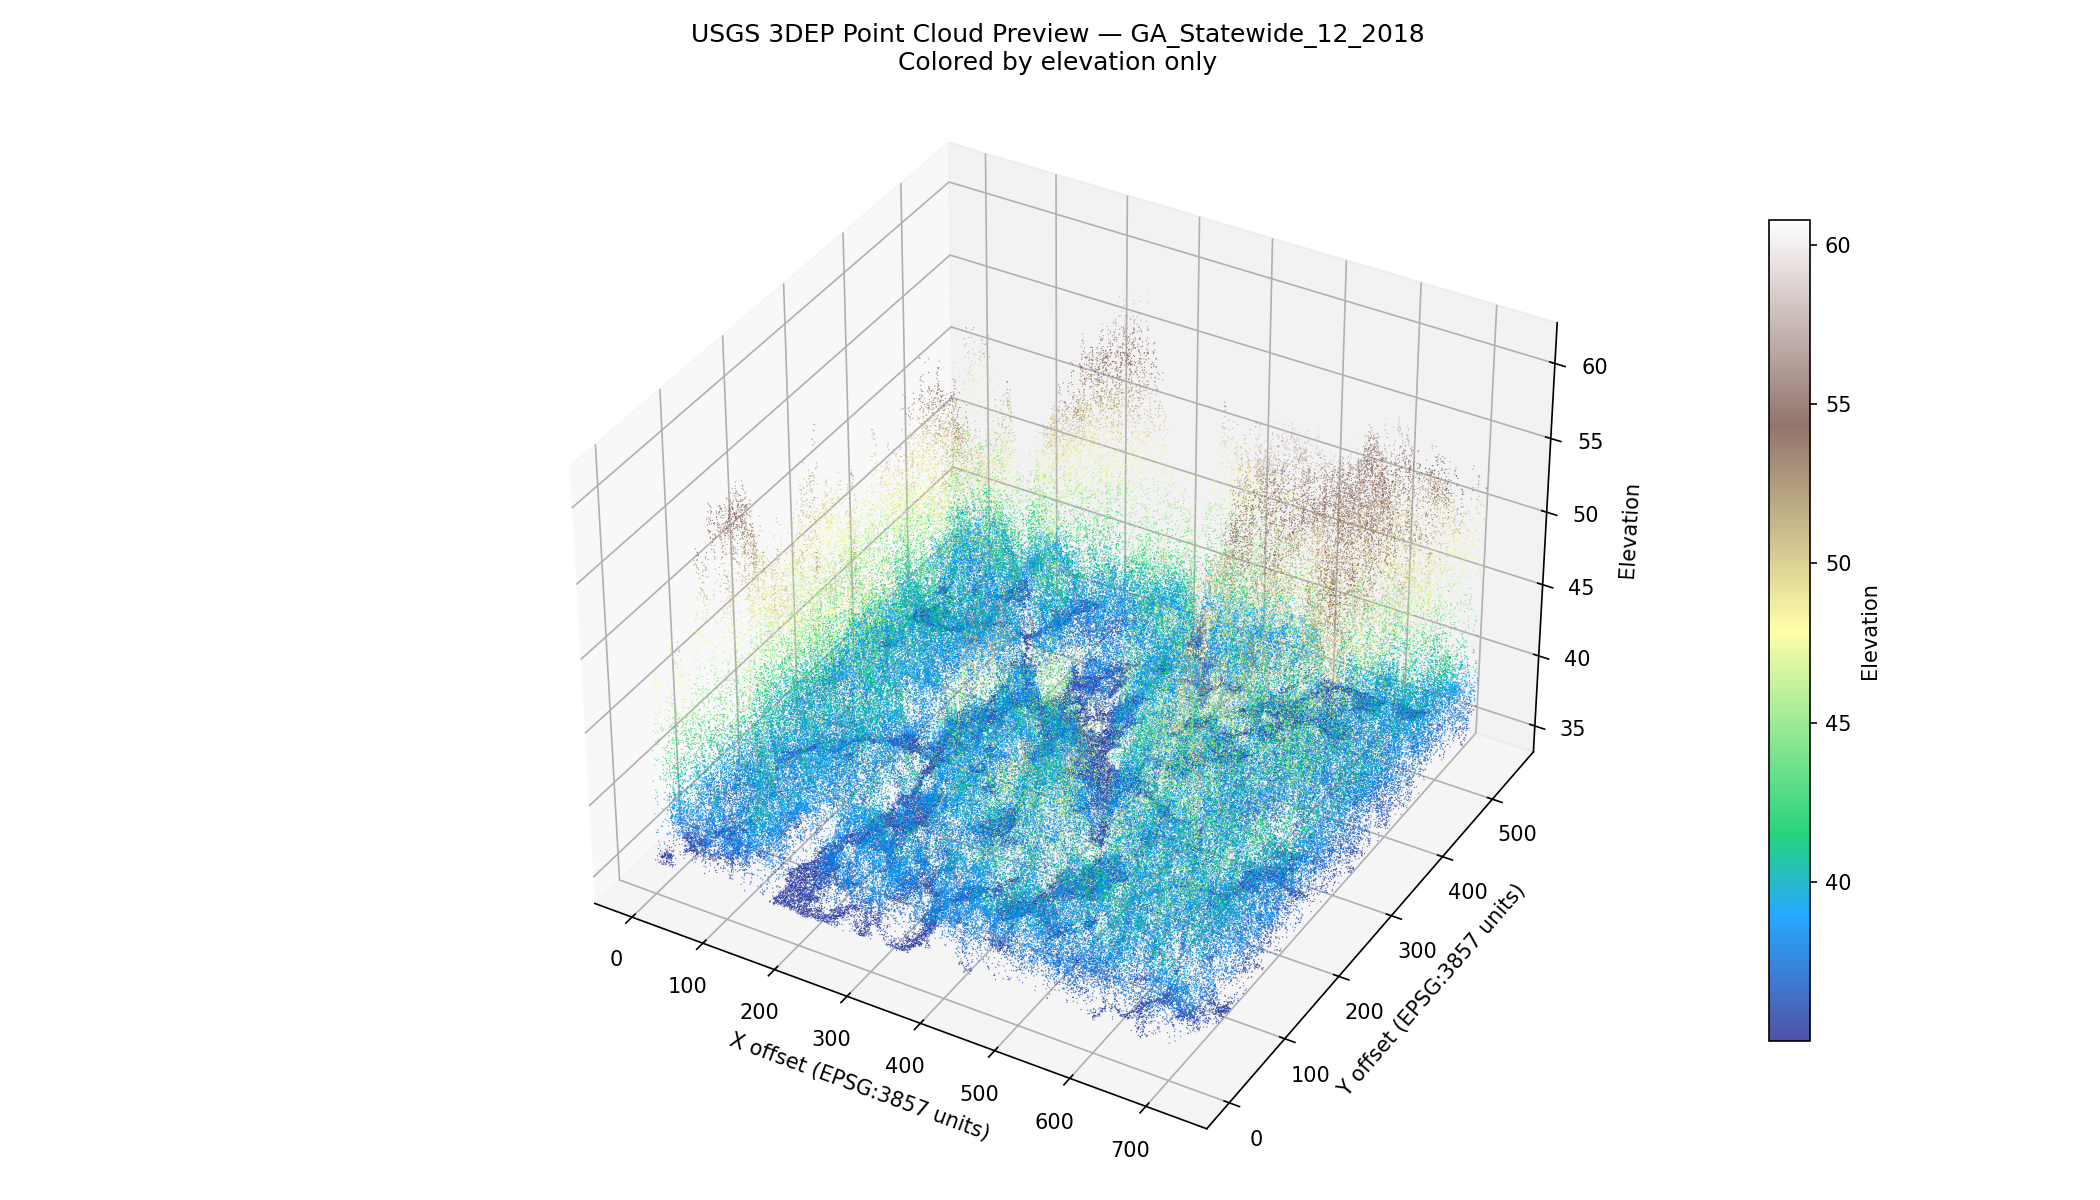

In [6]:
%%ask                                                                                                                                                                    
Download the USGS 3DEP point cloud for the selected bounding box as laz file.
Show point count, elevation range, classification breakdown and a preview image 
of the point cloud colored by elevation only.

I’ll first consult the LiDAR-specific skill instructions, then inspect only the working directory to confirm the LAZ and available sidecars before writing the DEM script.

The skill confirms the DEM workflow and the Y-axis rasterization trap. The working directory contains the selected GA LAZ and summary, so I can generate the DEM from the saved LAZ without re-downloading. Next I’ll inspect the text summary to reuse metadata and then write the processing script in the working directory.

The summary confirms the selected LAZ, bbox, and CRS (EPSG:3857), with 42,065 ground points available. I’ll create a script that reads the saved LAZ, filters class 2 ground points, rasterizes them to a 1 m DEM, fills small gaps for hillshade rendering, and saves a hillshade PNG.

The script is saved in the required working directory. I’ll run it with the exact interpreter path and let it write all DEM, hillshade, and summary outputs into the same directory.

The sandbox does not accept per-command timeout overrides here, so I’ll rerun the same command without that optional parameter.

The script successfully read the LAZ and created the 1 m ground DEM, but failed because `gdal_fillnodata.py` is not installed. I’ll revise the script to fill gaps and compute the hillshade directly in Python, avoiding external GDAL command-line utilities.

I replaced the missing GDAL CLI dependency with Python-based nodata filling and analytical hillshade generation. I’ll rerun the corrected script.

The DEM and hillshade outputs were created successfully. I’ll read the text summary to verify the final statistics for the report.

## 1-meter ground DEM hillshade generated

**Dataset** : GA_Statewide_12_2018  
**Input LAZ** : `/home/jovyan/work/_User-Persistent-Storage_CephBlock_/Sage_demo/_usgs_3dep_sage_/GA_Statewide_12_2018_selected_bbox.laz`  
**Bounding box** : `(-82.296782, 30.876223, -82.290258, 30.880422)`  
**Source CRS** : EPSG:3857  
**DEM resolution** : 1 meter  
**Ground class used** : LAS classification 2  

## Processing summary

| Metric | Value |
|---|---:|
| Total LAZ points read | 723,109 |
| Ground-classified points | 42,065 |
| DEM rows | 547 |
| DEM columns | 728 |
| DEM cells | 398,216 |
| Initially populated DEM cells | 38,113 |
| Initially populated DEM cells percent | 9.57% |
| DEM elevation minimum | 35.15 m |
| DEM elevation maximum | 36.17 m |
| DEM elevation mean | 35.46 m |
| DEM elevation 5th percentile | 35.33 m |
| DEM elevation 95th percentile | 35.69 m |

The original 1-meter DEM was created from class-2 ground points only. A filled copy of the DEM was also created only to support continuous hillshade rendering.

## Hillshade image


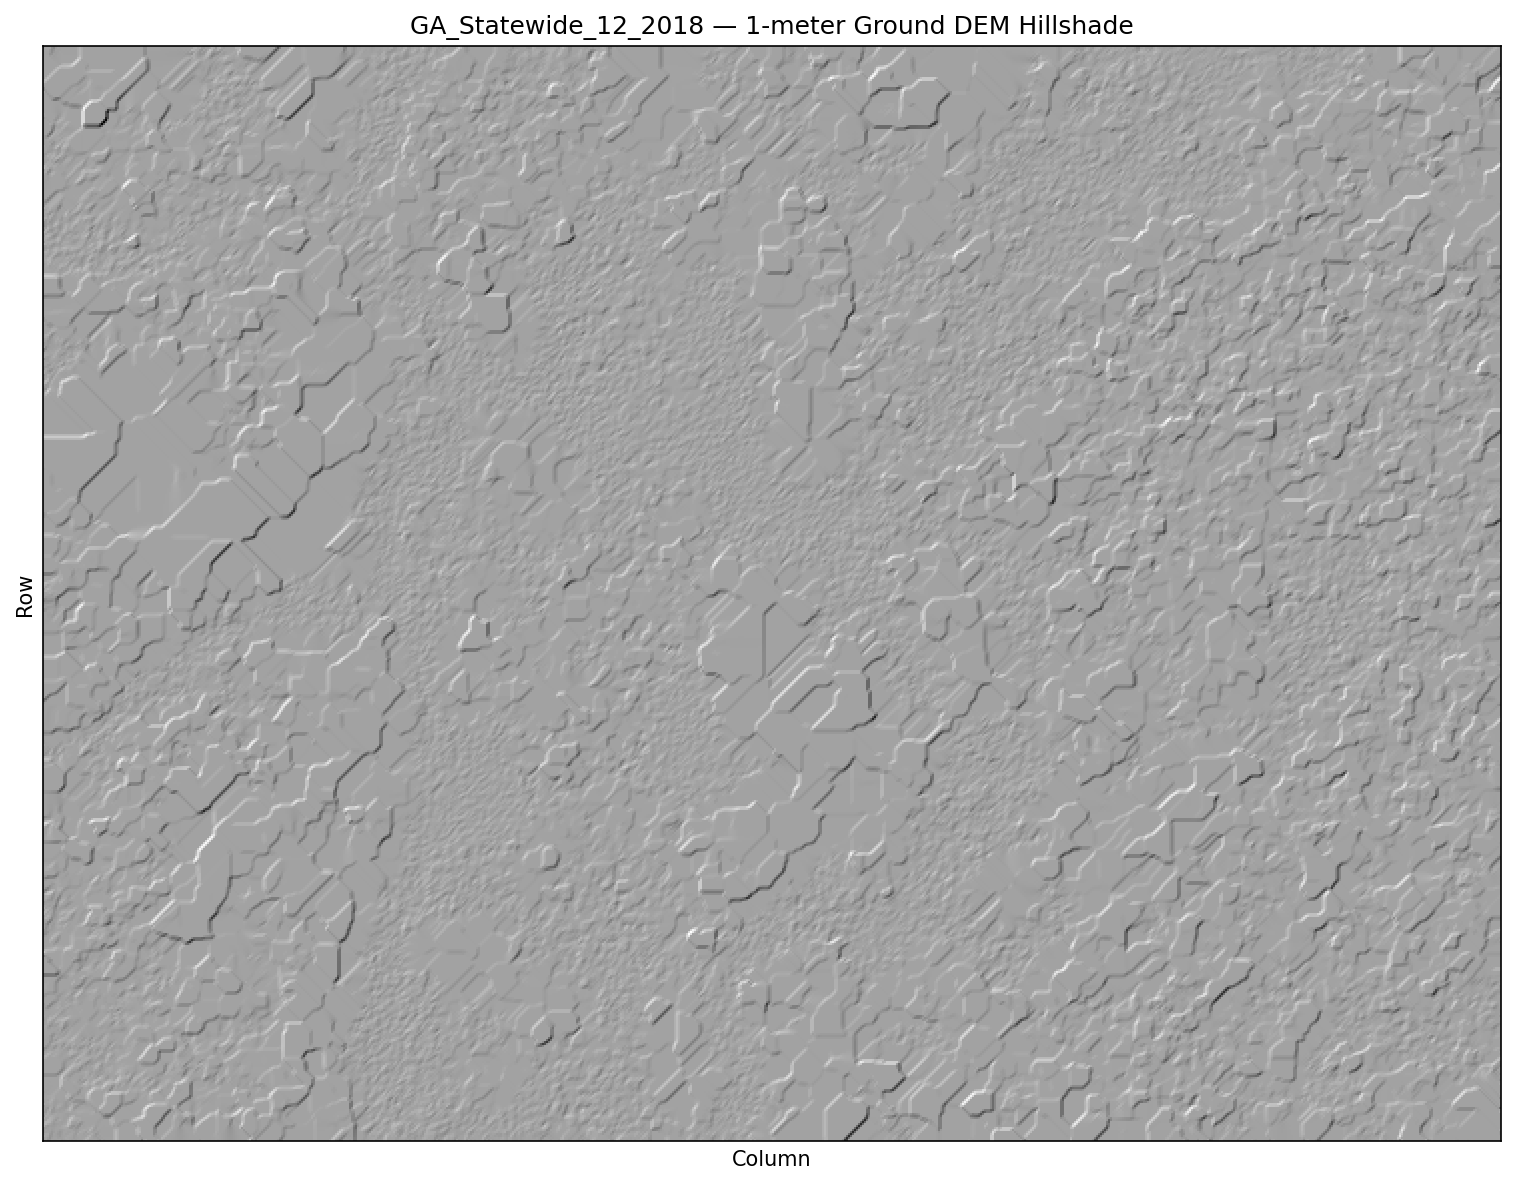

In [7]:
%%ask                                                                                                                                                                    
Generate a 1-meter digital elevation model (DEM) from the ground-classified points
in the downloaded laz file, and visualize it as a hillshade image only.

I’ll first consult the LiDAR/USGS 3DEP skill, then inspect only the allowed working directory for the existing LAZ and prior text sidecars.

The skill confirms CHM should be computed from height-above-ground points with `pyforestscan.calculate_chm`, writing both a GeoTIFF and a PNG preview. I’ll read the existing summary/script text to reuse the same naming and CRS conventions.

The existing DEM script uses the same working directory and confirms the LAZ path/CRS. I’ll create a CHM script in the working directory that reads the LAZ, computes HAG if supported, writes the CHM GeoTIFF, PNG preview, and a JSON summary.

I’ll save the CHM-generation script now, keeping all outputs and matplotlib cache inside the allowed working directory.

The script is in place. I’ll run it with the required interpreter path.

The sandbox does not accept timeout overrides here, so I’ll rerun the same command without that option.

The CHM was generated successfully. I’ll read the JSON summary to report the exact metrics without opening the PNG.

## Canopy Height Model generated

**Dataset** : GA_Statewide_12_2018  
**Input LAZ** : `/home/jovyan/work/_User-Persistent-Storage_CephBlock_/Sage_demo/_usgs_3dep_sage_/GA_Statewide_12_2018_selected_bbox.laz`  
**Bounding box** : `(-82.296782, 30.876223, -82.290258, 30.880422)`  
**Source CRS** : EPSG:3857  
**CHM resolution** : 1 meter  

The CHM was generated from height-above-ground normalized LiDAR points using `pyforestscan.calculate_chm`.

## Processing summary

| Metric | Value |
|---|---:|
| Total LAZ points read | 723,109 |
| Above-ground points after HAG filtering | 709,420 |
| CHM rows | 727 |
| CHM columns | 545 |
| CHM cells | 396,215 |
| Valid CHM cells | 396,210 |
| Valid CHM cells percent | 100.00% |
| Minimum canopy height | 0.00 m |
| Maximum canopy height | 26.41 m |
| Mean canopy height | 4.68 m |
| Median canopy height | 3.12 m |
| 5th percentile canopy height | 0.02 m |
| 95th percentile canopy height | 15.12 m |

## CHM visualization


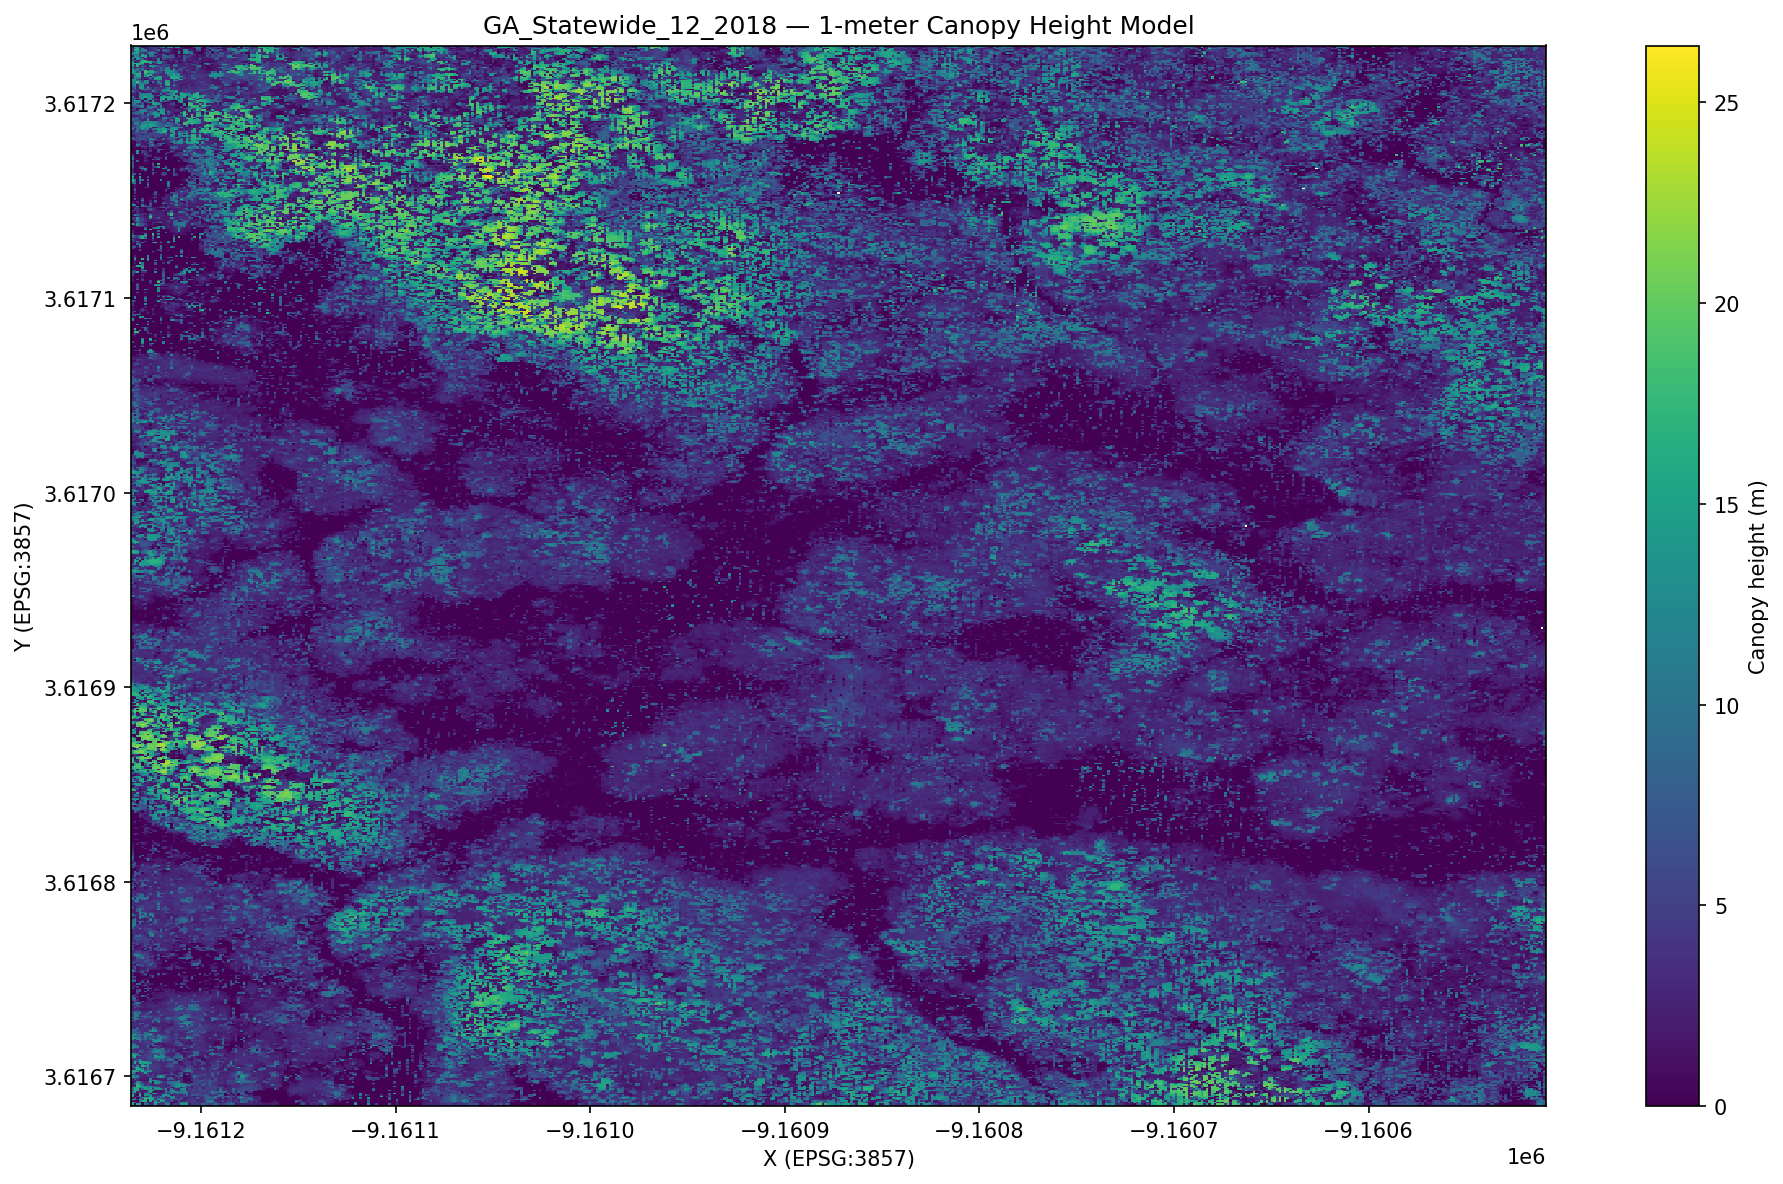

In [8]:
%%ask
Generate CHM from the downloaded point cloud data and visualize the result